# Repetition Lag-Rank Analysis

> Per-presentation temporal factor scores for transitions from repeated items.

The repetition lag-rank analysis decomposes temporal organization by which
presentation of a repeated item a transition originates from. For each
qualifying transition (from an item studied at least twice with sufficient
spacing), the absolute lag from each study position is ranked among all
available lags from that position. A score of 0.5 indicates chance;
scores above 0.5 reflect temporal contiguity.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `trial_query` | Query selecting trials to analyze |
| `min_lag` | Minimum spacing between repeated presentations |
| `size` | Max study positions an item can occupy |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.replagrank import (
    replagrank,
    plot_rep_lagrank,
    subject_rep_lagrank,
    test_rep_lagrank_vs_control,
    test_first_second_bias,
    RepLagRankTestResult,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
trial_query = "data['list_type'] > 2"
min_lag = 4
size = 2

In [4]:
#| code-summary: Load data
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)

data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

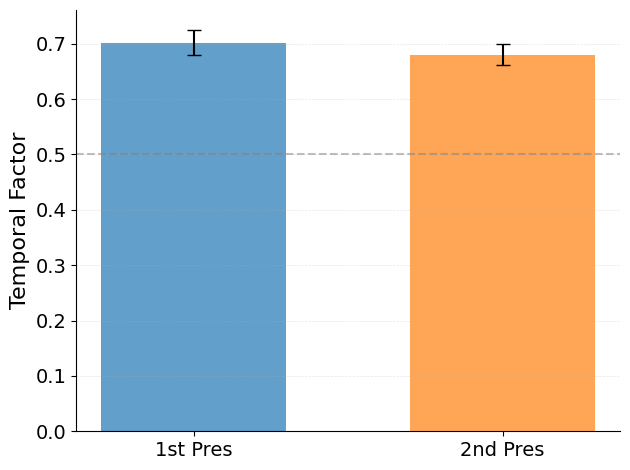

In [5]:
#| code-summary: Plot repetition lag-rank factors
#| label: fig-replagrank
#| fig-cap: "Per-presentation temporal factor score. Dashed line indicates chance (0.5)."
plot_rep_lagrank(data, trial_mask, min_lag=min_lag, size=size, labels=["1st Pres", "2nd Pres"])
save_figure(figure_dir, figure_str)

## Statistical Tests

In [6]:
#| code-summary: Test per-presentation temporal factors
factors = subject_rep_lagrank(data, trial_mask, min_lag=min_lag, size=size)

print()
print("=" * 60)
print("Per-Presentation Temporal Factor")
print("=" * 60)
print(f"N = {factors.shape[0]} subjects")
import numpy as np
for k in range(size):
    print(f"  Presentation {k+1}: mean = {np.nanmean(factors[:, k]):.4f}")
print()
print("Both presentations show temporal contiguity (factor > 0.5).")


Per-Presentation Temporal Factor
N = 35 subjects
  Presentation 1: mean = 0.7020
  Presentation 2: mean = 0.6791

Both presentations show temporal contiguity (factor > 0.5).


---

## Reference

In [7]:
#| echo: false
show_doc(plot_rep_lagrank)

---

### plot_rep_lagrank

>      plot_rep_lagrank (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],ja
>                        xcmr.typing.RecallDataset], trial_masks:Union[Sequence[
>                        jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bool[Arr
>                        ay,'trial_count']], min_lag:int=4, size:int=2,
>                        color_cycle:Optional[list[str]]=None,
>                        labels:Optional[Sequence[str]]=None,
>                        contrast_name:Optional[str]=None,
>                        axis:Optional[matplotlib.axes._axes.Axes]=None,
>                        confidence_level:float=0.95)

*Plot per-presentation lag-rank factors as a grouped bar chart.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| size | int | 2 | Maximum presentations per item. |
| color_cycle | Optional | None | Colors for each bar. |
| labels | Optional | None | Labels for each presentation bar. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the grouped bar chart.** |

In [8]:
#| echo: false
show_doc(replagrank)

---

### replagrank

>      replagrank (dataset:jaxcmr.typing.RecallDataset, min_lag:int=4,
>                  size:int=2)

*Compute per-trial per-presentation lag-rank factors for repeated items.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls`` and ``pres_itemnos``. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **Float[Array, 'trials size']** |  | **Per-trial temporal factor for each presentation index.** |

In [9]:
#| echo: false
show_doc(subject_rep_lagrank)

---

### subject_rep_lagrank

>      subject_rep_lagrank (dataset:jaxcmr.typing.RecallDataset,
>                           trial_mask:jaxtyping.Bool[Array,'trial_count'],
>                           min_lag:int=4, size:int=2)

*Compute per-subject per-presentation mean lag-rank factor.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **ndarray** |  | **Shape ``(n_subjects, size)``.** |

In [10]:
#| echo: false
show_doc(test_rep_lagrank_vs_control)

---

### test_rep_lagrank_vs_control

>      test_rep_lagrank_vs_control (observed:numpy.ndarray,
>                                   control:numpy.ndarray)

*Test observed vs control per-presentation lag-rank factors.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| observed | ndarray | Per-subject factors, shape ``(n_subjects, size)``. |
| control | ndarray | Per-subject control factors, same shape. |
| **Returns** | **dict** | **Results keyed by presentation label.** |

In [11]:
#| echo: false
show_doc(test_first_second_bias)

---

### test_first_second_bias

>      test_first_second_bias (observed:numpy.ndarray, control:numpy.ndarray)

*Test whether first-presentation temporal factor bias differs from control.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| observed | ndarray | Per-subject factors, shape ``(n_subjects, size)``. |
| control | ndarray | Per-subject control factors, same shape. |
| **Returns** | **RepLagRankTestResult** | **Test of (obs_first - obs_second) vs (ctrl_first - ctrl_second).** |

In [12]:
# Both presentations should show temporal contiguity for LohnasKahana2014
assert np.nanmean(factors[:, 0]) > 0.5, "First presentation factor should exceed chance"
assert np.nanmean(factors[:, 1]) > 0.5, "Second presentation factor should exceed chance"